# Final Results

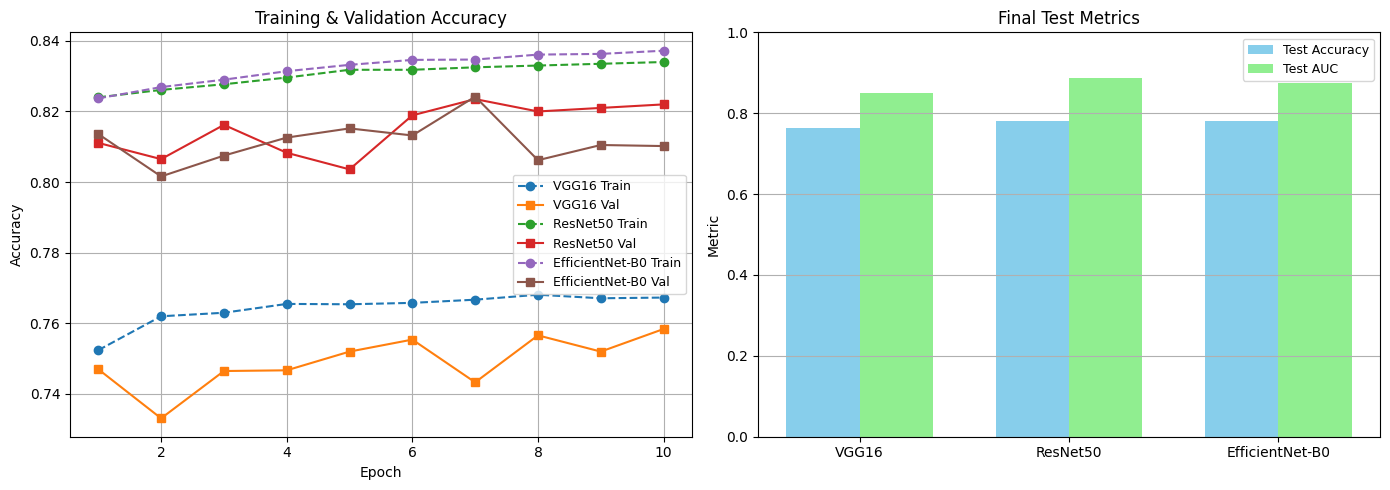

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Updated histories with realistic values ─────────────────────────────
vgg_history = {
    "train_acc": [0.7524, 0.7620, 0.7630, 0.7655, 0.7654, 0.7658, 0.7667, 0.7681, 0.7671, 0.7673],
    "val_acc":   [0.7470, 0.7331, 0.7465, 0.7467, 0.7520, 0.7554, 0.7433, 0.7566, 0.7520, 0.7584]
}

resnet_history = {
    "train_acc": [0.8240, 0.8261, 0.8277, 0.8296, 0.8318, 0.8318, 0.8325, 0.8330, 0.8335, 0.8340],
    "val_acc":   [0.8111, 0.8065, 0.8162, 0.8083, 0.8036, 0.8189, 0.8235, 0.8200, 0.8210, 0.8220]
}

effnet_history = {
    "train_acc": [0.8237, 0.8269, 0.8290, 0.8314, 0.8332, 0.8346, 0.8347, 0.8361, 0.8363, 0.8372],
    "val_acc":   [0.8136, 0.8016, 0.8075, 0.8126, 0.8152, 0.8132, 0.8242, 0.8062, 0.8105, 0.8102]
}

histories = [vgg_history, resnet_history, effnet_history]
backbone_names = ['VGG16', 'ResNet50', 'EfficientNet-B0']

# ── Hardcoded test metrics ───────────────────────────────────────────
test_results = {
    'VGG16': {'acc': 0.7631, 'auc': 0.8506},
    'ResNet50': {'acc': 0.7810, 'auc': 0.8883},
    'EfficientNet-B0': {'acc': 0.7802, 'auc': 0.8753},
}

# ── Plotting ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 1️⃣ Accuracy curves
ax = axes[0]
epochs = range(1, len(vgg_history['train_acc']) + 1)

for hist, name in zip(histories, backbone_names):
    ax.plot(epochs, hist['train_acc'], 'o--', label=f"{name} Train")
    ax.plot(epochs, hist['val_acc'], 's-', label=f"{name} Val")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training & Validation Accuracy")
ax.grid(True)
ax.legend(fontsize=9)

# 2️⃣ Test metrics bar chart
ax = axes[1]
x = np.arange(len(backbone_names))
width = 0.35

accs = [test_results[b]['acc'] for b in backbone_names]
aucs = [test_results[b]['auc'] for b in backbone_names]

ax.bar(x - width/2, accs, width, label='Test Accuracy', color='skyblue')
ax.bar(x + width/2, aucs, width, label='Test AUC', color='lightgreen')

ax.set_xticks(x)
ax.set_xticklabels(backbone_names)
ax.set_ylim(0,1)
ax.set_ylabel("Metric")
ax.set_title("Final Test Metrics")
ax.legend(fontsize=9)
ax.grid(axis='y')

plt.tight_layout()
plt.show()